In [1]:
import os, pickle
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotters.gcd_plotter import plot_gcd_curves, load_gcd_data
from plotters.rate_plotter import plot_rate_performance

Dropdown(description='Plot Type:', options=('GCD', 'Rate', 'CV'), value='GCD')

Dropdown(description='Sample:', options=('1-lg', '12-10% Iodine - co-infiltration', '29-20%_ iodine - co-infil…

SelectMultiple(description='File(s):', layout=Layout(height='100px'), options=(), value=())

Text(value='', description='Cycles:', placeholder='e.g. 1,2,3 or leave blank')

Checkbox(value=False, description='Half-cycles separate colors')

...

Button(button_style='danger', description='Remove Sample', style=ButtonStyle())

Checkbox(value=True, description='Show Grid')

Dropdown(description='Color Scheme:', options=('default', 'viridis', 'plasma', 'cividis', 'magma', 'inferno', …

Button(button_style='success', description='Plot', style=ButtonStyle())

Output()

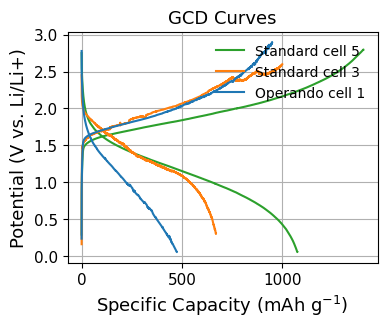

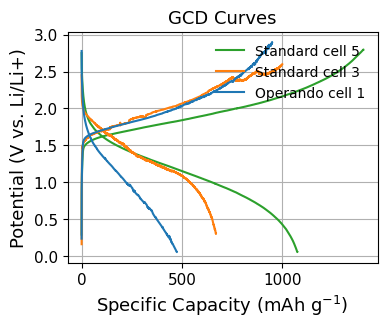

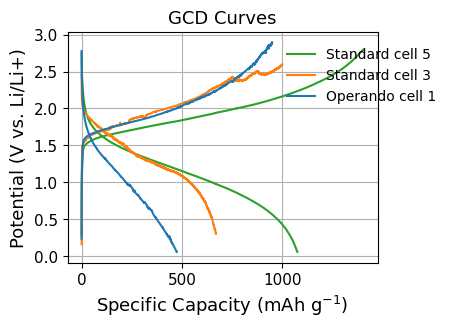

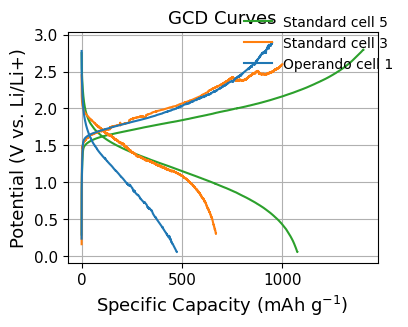

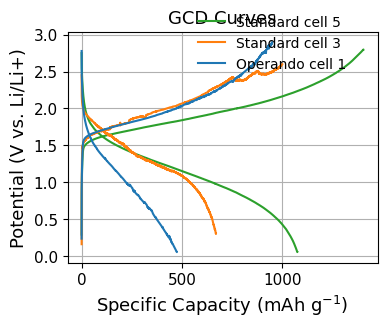

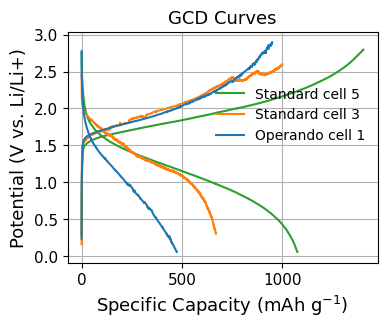

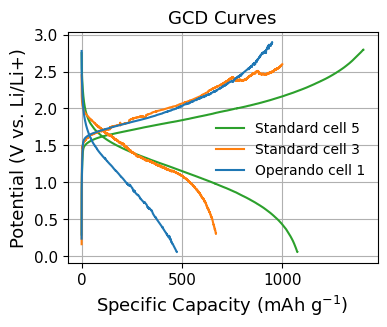

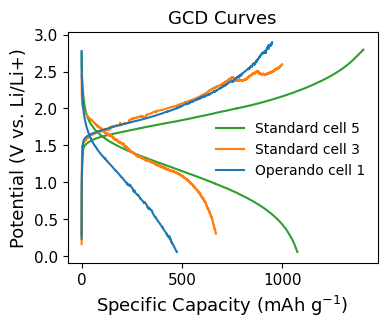

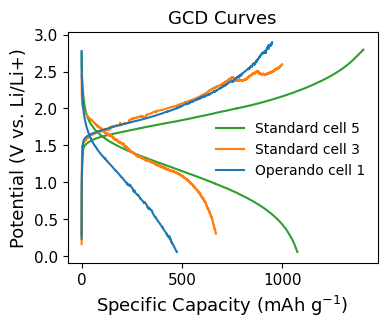

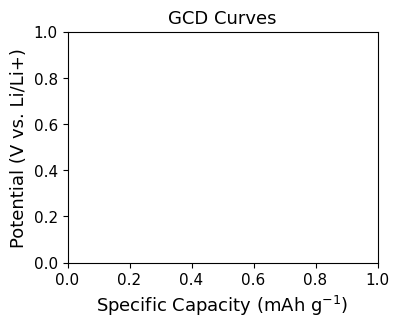

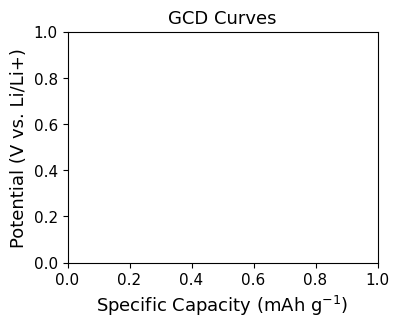

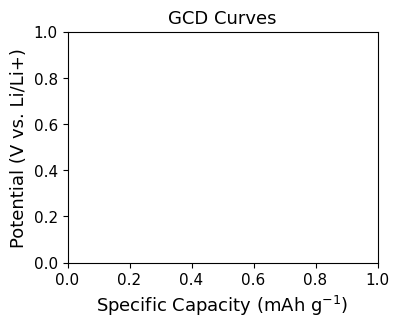

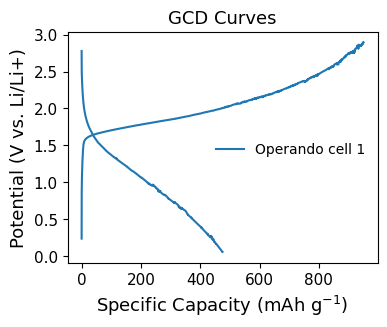

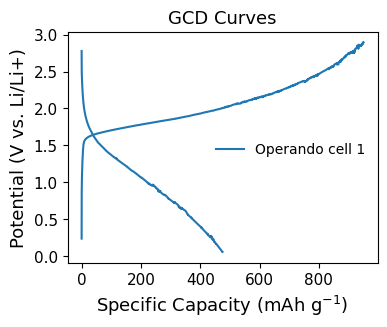

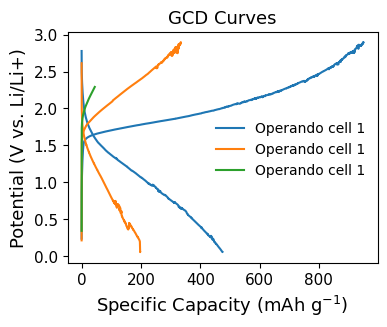

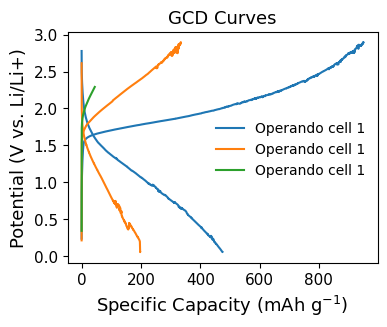

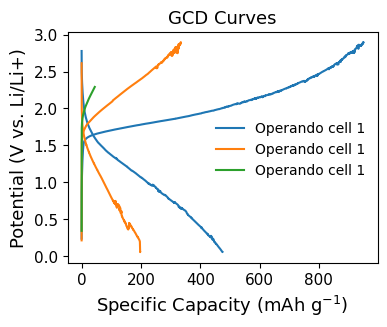

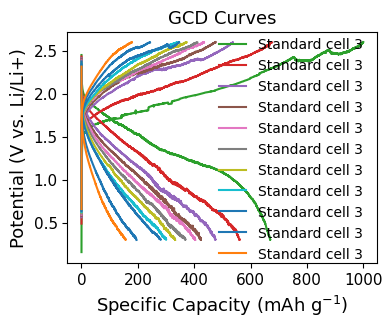

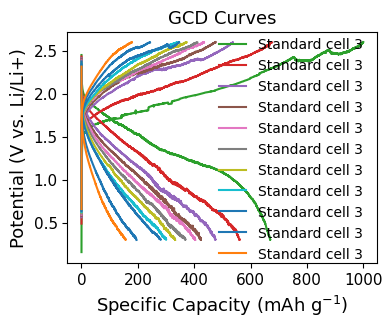

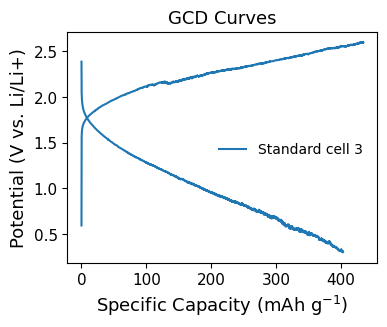

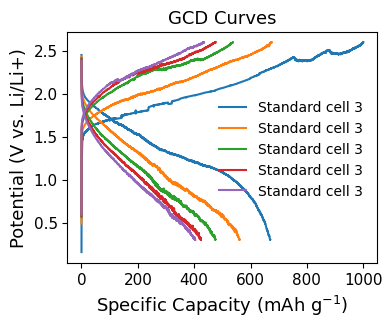

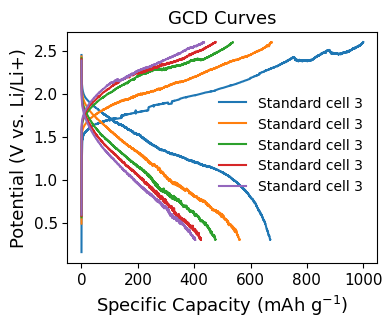

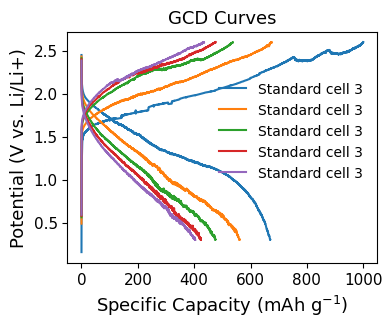

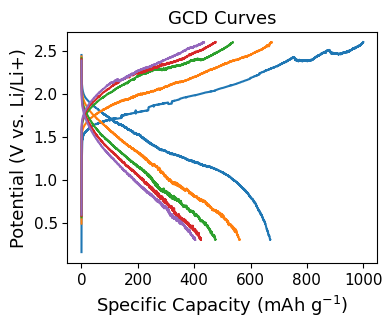

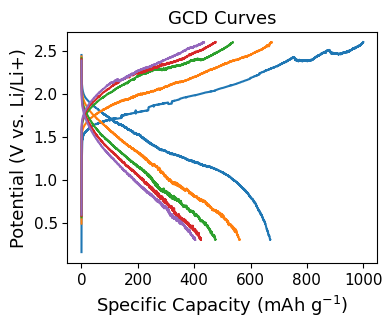

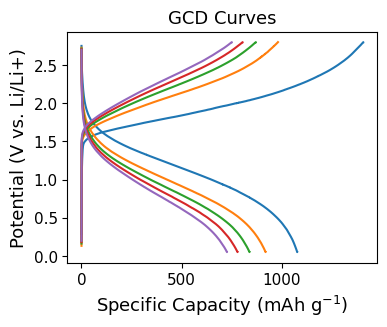

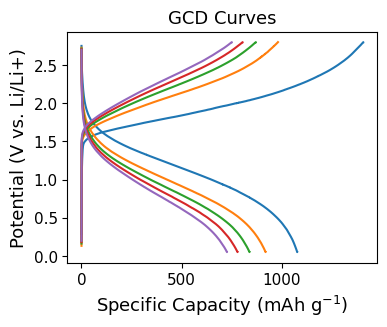

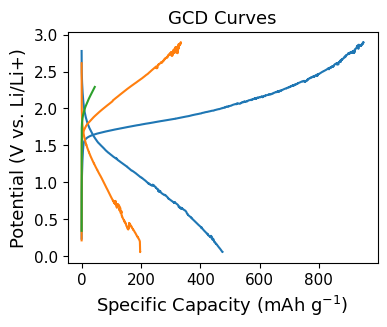

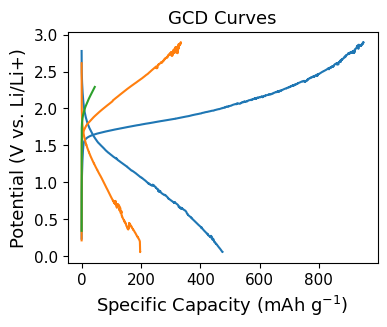

In [ ]:
import os
import json
import pickle
from datetime import datetime
import math
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotters import gcd_plotter, rate_plotter  # Assumes both plot functions exist
import importlib  # ensure updated plotter is used during interactive edits
importlib.reload(rate_plotter)
importlib.reload(gcd_plotter)

# --- Simple persistence for last selected project folder ---
CONFIG_FILE = os.path.expanduser("~/.saxs_waxs_gui_state.json")

def _save_last_project(path: str):
    try:
        with open(CONFIG_FILE, "w") as f:
            json.dump({"last_project_folder": path}, f)
    except Exception:
        # Persistence is best-effort; ignore failures
        pass

def _load_last_project() -> str | None:
    try:
        if os.path.isfile(CONFIG_FILE):
            with open(CONFIG_FILE) as f:
                cfg = json.load(f)
            p = cfg.get("last_project_folder")
            if p and os.path.isdir(p):
                return p
    except Exception:
        pass
    return None

# Helper to get/save directory for figures
def _get_save_dir():
    base = project_folder.value if os.path.isdir(project_folder.value) else os.getcwd()
    out = os.path.join(base, "Figures")
    os.makedirs(out, exist_ok=True)
    return out

# --- Plot Type Selection ---
plot_type_dd = widgets.Dropdown(
    options=["GCD", "Rate", "CV"],
    value="GCD",
    description="Plot Type:"
 )

# --- Project Folder Selection ---
project_folder = widgets.Text(
    value="",
    placeholder="Select your project folder",
    description="Project:",
    layout=widgets.Layout(width="70%")
 )
browse_btn = widgets.Button(description="Browse…", layout=widgets.Layout(width="15%"))

# Load previously used folder, if available
_last = _load_last_project()
if _last:
    project_folder.value = _last

def on_browse_clicked(_):
    from tkinter import Tk, filedialog
    tkroot = Tk(); tkroot.withdraw()
    folder = filedialog.askdirectory()
    tkroot.destroy()
    if folder:
        project_folder.value = folder
        # update_sample_options() will be triggered by observers

browse_btn.on_click(on_browse_clicked)
folder_box = widgets.HBox([project_folder, browse_btn])

# --- Sample + File + Cycles + Label ---
sample_select = widgets.Dropdown(description="Sample:")
file_select = widgets.SelectMultiple(description="File(s):", layout=widgets.Layout(height='100px'))
cycle_input = widgets.Text(placeholder="e.g. 1,2,3 or leave blank", description="Cycles:")
halfcycle_color_cb = widgets.Checkbox(value=False, description="Half-cycles separate colors")
label_input = widgets.Text(value="", description="Label:")

# --- Rate-only Inputs ---
theory_cap_input = widgets.FloatText(value=1675, description="Theoretical (mAh/g):")
rate_cycle_range = widgets.Text(value="1-3", description="Cycles to use:")
# New: C-rate label mode control
c_rate_label_mode_dd = widgets.Dropdown(
    options=["No", "Over all plots", "On top"],
    value="Over all plots",
    description="C-rate labels:")
rate_box = widgets.VBox([theory_cap_input, rate_cycle_range, c_rate_label_mode_dd])
rate_box.layout.display = 'none'

# Show/hide depending on plot type
def update_rate_widgets(*_):
    rate_box.layout.display = 'flex' if plot_type_dd.value == "Rate" else 'none'

plot_type_dd.observe(update_rate_widgets, names="value")

# --- Sample Addition ---
add_sample_btn = widgets.Button(description="Add Sample", button_style='info')
sample_preview = widgets.Output()
selected_samples = []  # Dicts: {sample, files, cycles, label}

def list_available_samples():
    base = project_folder.value
    selected_type = plot_type_dd.value
    result = []

    if os.path.isdir(base):
        for name in sorted(os.listdir(base)):
            sample_dir = os.path.join(base, name)
            if os.path.isdir(sample_dir):
                if selected_type == "GCD":
                    if any(os.path.isdir(os.path.join(sample_dir, f)) for f in ["GCD", "Rate"]):
                        result.append(name)
                else:
                    if os.path.isdir(os.path.join(sample_dir, selected_type)):
                        result.append(name)
    return result

def list_csv_files(sample, plot_type):
    base = os.path.join(project_folder.value, sample)
    files = []

    if plot_type == "GCD":
        for subfolder in ["GCD", "Rate"]:
            folder = os.path.join(base, subfolder)
            if os.path.isdir(folder):
                for f in os.listdir(folder):
                    if f.endswith(".csv"):
                        files.append(os.path.join(subfolder, f))
    else:
        folder = os.path.join(base, plot_type)
        if os.path.isdir(folder):
            for f in os.listdir(folder):
                if f.endswith(".csv"):
                    files.append(os.path.join(plot_type, f))

    return sorted(files)

def update_sample_options(*_):
    sample_select.options = list_available_samples()
    update_file_options()

def update_file_options(*_):
    sample = sample_select.value
    if sample:
        file_select.options = list_csv_files(sample, plot_type_dd.value)

# Update lists when inputs change
project_folder.observe(update_sample_options, names="value")
sample_select.observe(update_file_options, names="value")
plot_type_dd.observe(update_sample_options, names="value")

# Persist project folder whenever it changes
def _on_project_folder_change(change):
    p = str(change.get("new", "")).strip()
    if p and os.path.isdir(p):
        _save_last_project(p)
project_folder.observe(_on_project_folder_change, names="value")

# If we already have a folder (from persistence), populate options now
if project_folder.value:
    update_sample_options()

def on_add_sample(_):
    sample = sample_select.value
    files = list(file_select.value)
    label = label_input.value.strip()
    if not sample or not files:
        print("⚠️ Please select sample and file(s).")
        return
    try:
        cycles = [int(c.strip()) for c in cycle_input.value.split(",") if c.strip()]
    except:
        cycles = None

    selected_samples.append({
        "sample": sample,
        "files": files,
        "cycles": cycles,
        "label": label
    })
    with sample_preview:
        print(f"✓ Added: {sample} | Files: {files} | Cycles: {cycles if cycles else 'All'} | Label: {label}")
    update_remove_sample_options()

add_sample_btn.on_click(on_add_sample)

# --- Remove Sample ---
remove_sample_dd = widgets.Dropdown(description="Remove Sample:")
remove_sample_btn = widgets.Button(description="Remove Sample", button_style='danger')

def update_remove_sample_options():
    remove_sample_dd.options = [f"{s['sample']} | {s['label']}" for s in selected_samples]
update_remove_sample_options()

def on_remove_sample(_):
    idx = remove_sample_dd.index if remove_sample_dd.options else None
    if idx is not None and idx < len(selected_samples):
        removed = selected_samples.pop(idx)
        with sample_preview:
            clear_output()
            print(f"✗ Removed: {removed['sample']} | Label: {removed['label']}")
            for s in selected_samples:
                print(f"✓ Added: {s['sample']} | Files: {s['files']} | Cycles: {s['cycles'] if s['cycles'] else 'All'} | Label: {s['label']}")
        update_remove_sample_options()
    else:
        with sample_preview:
            print("⚠️ No sample selected to remove.")
remove_sample_btn.on_click(on_remove_sample)

# --- Grid, Color Scheme, Legend ---
grid_checkbox = widgets.Checkbox(value=True, description="Show Grid")
color_scheme_dd = widgets.Dropdown(
    options=["default", "viridis", "plasma", "cividis", "magma", "inferno", "tab10", "Set1", "Pastel1"],
    value="default",
    description="Color Scheme:",
 )
legend_mode_dd = widgets.Dropdown(
    options=["Corner", "Manual"],
    value="Corner",
    description="Legend Mode:",
 )
legend_loc_dd = widgets.Dropdown(
    options=["upper right", "upper left", "lower left", "lower right"],
    value="upper right",
    description="Legend:",
 )
legend_x = widgets.FloatSlider(value=0.95, min=0.0, max=1.0, step=0.01, description="Legend X:")
legend_y = widgets.FloatSlider(value=0.95, min=0.0, max=1.0, step=0.01, description="Legend Y:")
legend_drag_cb = widgets.Checkbox(value=False, description="Legend draggable")
legend_hide_cb = widgets.Checkbox(value=False, description="Hide legend")
# 
def _toggle_legend_controls(*_):
    if legend_mode_dd.value == "Corner":
        legend_loc_dd.layout.display = 'flex'
        legend_x.layout.display = 'none'
        legend_y.layout.display = 'none'
    else:
        legend_loc_dd.layout.display = 'none'
        legend_x.layout.display = 'flex'
        legend_y.layout.display = 'flex'

_toggle_legend_controls()
legend_mode_dd.observe(_toggle_legend_controls, names="value")

legend_box = widgets.VBox([legend_mode_dd, legend_loc_dd, legend_x, legend_y, legend_drag_cb, legend_hide_cb])

# --- Axes Range Controls ---
x_range_mode_dd = widgets.Dropdown(options=["Auto", "Manual"], value="Auto", description="X Range:")
x_min_input = widgets.FloatText(value=0.0, description="X min:")
x_max_input = widgets.FloatText(value=0.0, description="X max:")
y_range_mode_dd = widgets.Dropdown(options=["Auto", "Manual"], value="Auto", description="Y Range:")
y_min_input = widgets.FloatText(value=0.0, description="Y min:")
y_max_input = widgets.FloatText(value=0.0, description="Y max:")

def _toggle_axis_inputs(*_):
    x_vis = 'flex' if x_range_mode_dd.value == 'Manual' else 'none'
    y_vis = 'flex' if y_range_mode_dd.value == 'Manual' else 'none'
    x_min_input.layout.display = x_vis
    x_max_input.layout.display = x_vis
    y_min_input.layout.display = y_vis
    y_max_input.layout.display = y_vis

_toggle_axis_inputs()
x_range_mode_dd.observe(_toggle_axis_inputs, names='value')
y_range_mode_dd.observe(_toggle_axis_inputs, names='value')
axes_box = widgets.VBox([x_range_mode_dd, x_min_input, x_max_input, y_range_mode_dd, y_min_input, y_max_input])

def _build_axis_limits():
    # Returns (xlim, ylim) tuples or None if Auto/invalid
    def _safe_range(mode, vmin, vmax):
        if mode != 'Manual':
            return None
        try:
            a = float(vmin)
            b = float(vmax)
        except Exception:
            return None
        if not (math.isfinite(a) and math.isfinite(b)):
            return None
        if a == b:
            return None
        # Auto-correct if min > max
        if a > b:
            a, b = b, a
        return (a, b)
    return _safe_range(x_range_mode_dd.value, x_min_input.value, x_max_input.value), _safe_range(y_range_mode_dd.value, y_min_input.value, y_max_input.value)

# --- Save Plot Controls (SVG) ---
save_svg_cb = widgets.Checkbox(value=False, description="Save as SVG")
save_filename = widgets.Text(value="", placeholder="optional filename (without .svg)", description="Filename:")
save_transparent_cb = widgets.Checkbox(value=True, description="Transparent bg")

def _toggle_save_controls(*_):
    vis = 'flex' if save_svg_cb.value else 'none'
    save_filename.layout.display = vis
    save_transparent_cb.layout.display = vis

_toggle_save_controls()
save_svg_cb.observe(_toggle_save_controls, names="value")
save_box = widgets.VBox([save_svg_cb, save_filename, save_transparent_cb])

# --- Save Plot Controls (PNG) ---
save_png_cb = widgets.Checkbox(value=False, description="Save as PNG")
png_filename = widgets.Text(value="", placeholder="optional filename (without .png)", description="Filename:")
png_dpi = widgets.BoundedIntText(value=300, min=72, max=1200, step=1, description="DPI:")
png_transparent_cb = widgets.Checkbox(value=True, description="Transparent bg")

def _toggle_save_png_controls(*_):
    vis = 'flex' if save_png_cb.value else 'none'
    png_filename.layout.display = vis
    png_dpi.layout.display = vis
    png_transparent_cb.layout.display = vis

_toggle_save_png_controls()
save_png_cb.observe(_toggle_save_png_controls, names="value")
save_png_box = widgets.VBox([save_png_cb, png_filename, png_dpi, png_transparent_cb])

# --- Plot Button ---
plot_btn = widgets.Button(description="Plot", button_style='success')
output = widgets.Output()

# --- Update UI ---
def on_plot_clicked(_):
    with output:
        output.clear_output()
        if not selected_samples:
            print("Please add at least one sample.")
            return

        plot_type = plot_type_dd.value
        all_groups = []  # list of {label, data_dict, mass_dict}

        for entry in selected_samples:
            sample = entry["sample"]
            files = entry["files"]
            cycles = entry["cycles"]
            label = entry["label"]
            base_path = os.path.join(project_folder.value, sample)

            data = {}
            masses = {}

            for rel_path in files:
                full_path = os.path.join(base_path, rel_path)
                folder = os.path.dirname(full_path)

                meta_path_pkl = os.path.join(folder, "metadata.pkl")
                meta_path_json = os.path.join(folder, "meta.json")
                mass_mg = 1.0

                if os.path.isfile(meta_path_pkl):
                    with open(meta_path_pkl, "rb") as f:
                        meta = pickle.load(f)
                    mass_mg = float(meta.get("mass_mg", 1.0))
                elif os.path.isfile(meta_path_json):
                    with open(meta_path_json) as f:
                        meta = json.load(f)
                    mass_mg = float(meta.get("mass_mg", 1.0))

                if not os.path.isfile(full_path):
                    print(f"⚠️ Missing file: {rel_path}")
                    continue

                try:
                    df = pd.read_csv(full_path)
                    if cycles:
                        df = df[df['cycle_number'].isin(cycles)]
                    key = f"{sample}_{os.path.splitext(os.path.basename(rel_path))[0]}"
                    data[key] = df
                    masses[key] = mass_mg
                except Exception as e:
                    print(f"❌ Failed to load {rel_path}: {e}")

            all_groups.append({
                "label": label if label else sample,
                "data": data,
                "masses": masses
            })

        if not all_groups:
            print("No valid data found.")
            return

        try:
            grid = grid_checkbox.value
            color_scheme = color_scheme_dd.value
            if legend_mode_dd.value == "Corner":
                legend_loc = legend_loc_dd.value
                legend_xy = None
            else:
                legend_loc = "center"
                legend_xy = (legend_x.value, legend_y.value)
            draggable = legend_drag_cb.value
            show_legend = not legend_hide_cb.value

            # Build axis ranges from UI (safe)
            xlim, ylim = _build_axis_limits()
            if x_range_mode_dd.value == 'Manual' and xlim is None:
                print("ℹ️ Ignoring X manual range: invalid or equal min/max.")
            if y_range_mode_dd.value == 'Manual' and ylim is None:
                print("ℹ️ Ignoring Y manual range: invalid or equal min/max.")

            if plot_type == "GCD":
                fig, ax = gcd_plotter.plot_gcd_curves(all_groups, grid=grid, color_scheme=color_scheme, separate_halfcycle_colors=halfcycle_color_cb.value, legend_loc=legend_loc, legend_xy=legend_xy, legend_draggable=draggable, xlim=xlim, ylim=ylim)
            elif plot_type == "Rate":
                cap = theory_cap_input.value
                cycle_range = rate_cycle_range.value.strip().replace("to", "-")
                start, end = [int(c.strip()) for c in cycle_range.split("-")]
                # Map UI selection to plotter keywords
                mode_map = {
                    "No": "none",
                    "Over all plots": "overall",
                    "On top": "on_top",
                }
                internal_mode = mode_map.get(c_rate_label_mode_dd.value, "overall")
                fig, ax = rate_plotter.plot_rate_performance(all_groups, cap, start, end, grid=grid, color_scheme=color_scheme, legend_loc=legend_loc, legend_xy=legend_xy, legend_draggable=draggable, c_rate_label_mode=internal_mode, xlim=xlim, ylim=ylim)
            else:
                print("⚠️ CV plotting not implemented yet.")
                return
            if not show_legend:
                leg = ax.get_legend()
                if leg is not None:
                    leg.remove()

            # Save as SVG if requested
            if save_svg_cb.value:
                name = save_filename.value.strip() or f"{plot_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
                if not name.lower().endswith(".svg"):
                    name += ".svg"
                out_dir = _get_save_dir()
                base_name, ext = os.path.splitext(name)
                out_path = os.path.join(out_dir, name)
                i = 1
                while os.path.exists(out_path):
                    out_path = os.path.join(out_dir, f"{base_name}_{i}{ext}")
                    i += 1
                try:
                    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=save_transparent_cb.value)
                    print(f"💾 Saved SVG to: {out_path}")
                except Exception as e:
                    print(f"❌ Failed to save SVG: {e}")

            # Save as PNG if requested
            if save_png_cb.value:
                name = png_filename.value.strip() or f"{plot_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
                if not name.lower().endswith(".png"):
                    name += ".png"
                out_dir = _get_save_dir()
                base_name, ext = os.path.splitext(name)
                out_path = os.path.join(out_dir, name)
                i = 1
                while os.path.exists(out_path):
                    out_path = os.path.join(out_dir, f"{base_name}_{i}{ext}")
                    i += 1
                try:
                    fig.savefig(out_path, format="png", dpi=int(png_dpi.value), bbox_inches="tight", transparent=png_transparent_cb.value)
                    print(f"💾 Saved PNG to: {out_path}")
                except Exception as e:
                    print(f"❌ Failed to save PNG: {e}")

            display(fig)

        except Exception as e:
            print(f"❌ Error while plotting: {e}")

plot_btn.on_click(on_plot_clicked)

# --- Display UI ---
display(folder_box)
display(plot_type_dd)
display(sample_select, file_select, cycle_input, halfcycle_color_cb, label_input, add_sample_btn)
display(rate_box)
display(sample_preview)
display(remove_sample_dd, remove_sample_btn)
display(grid_checkbox, color_scheme_dd)
display(legend_box)
display(axes_box)
display(save_box)
display(save_png_box)
display(plot_btn, output)